# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Iris Dataset**, salah satu dataset klasik dalam machine learning yang bersumber dari [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/iris) dan tersedia langsung melalui library `scikit-learn`.

Dataset ini terdiri dari **150 sampel** bunga iris dari tiga spesies berbeda:
- *Iris setosa*
- *Iris versicolor*
- *Iris virginica*

Setiap sampel memiliki 4 fitur numerik:
| Fitur | Deskripsi |
|---|---|
| sepal length (cm) | Panjang kelopak luar |
| sepal width (cm) | Lebar kelopak luar |
| petal length (cm) | Panjang kelopak dalam |
| petal width (cm) | Lebar kelopak dalam |

**Tujuan**: Membangun model klasifikasi untuk memprediksi spesies bunga iris berdasarkan keempat fitur tersebut.

# **2. Import Library**

Mengimpor seluruh library yang dibutuhkan untuk analisis data, visualisasi, preprocessing, dan pemodelan machine learning.

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Dataset
from sklearn.datasets import load_iris

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Untuk menyimpan dataset hasil preprocessing
import os

print('Library berhasil diimpor!')

Library berhasil diimpor!


# **3. Memuat Dataset**

Dataset Iris dimuat langsung dari `scikit-learn`, kemudian dikonversi ke dalam DataFrame pandas agar lebih mudah dianalisis.

In [2]:
# Load dataset Iris
iris = load_iris()

# Konversi ke DataFrame
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df['species_name'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Simpan raw dataset
os.makedirs('iris_raw', exist_ok=True)
df.to_csv('iris_raw/iris_raw.csv', index=False)
print('Raw dataset disimpan ke iris_raw/iris_raw.csv')

# Preview data
print(f'\nShape dataset: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}')
df.head(10)

Raw dataset disimpan ke iris_raw/iris_raw.csv

Shape dataset: (150, 6)
Jumlah baris: 150, Jumlah kolom: 6


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


In [3]:
# Informasi tipe data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
 5   species_name       150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
# Statistik deskriptif
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


# **4. Exploratory Data Analysis (EDA)**

Melakukan eksplorasi menyeluruh terhadap dataset untuk memahami distribusi data, hubungan antar fitur, dan karakteristik tiap kelas.

## 4.1 Pengecekan Missing Values dan Duplikasi

In [5]:
# Cek missing values
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

# Cek duplikasi
print(f'\n=== Duplikasi ===')
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

=== Missing Values ===
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Total missing values: 0

=== Duplikasi ===
Jumlah baris duplikat: 1


## 4.2 Distribusi Kelas (Target)

=== Distribusi Kelas ===
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


C:\Users\monar\AppData\Local\Temp\ipykernel_12168\1883629230.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='species_name', palette='Set2')


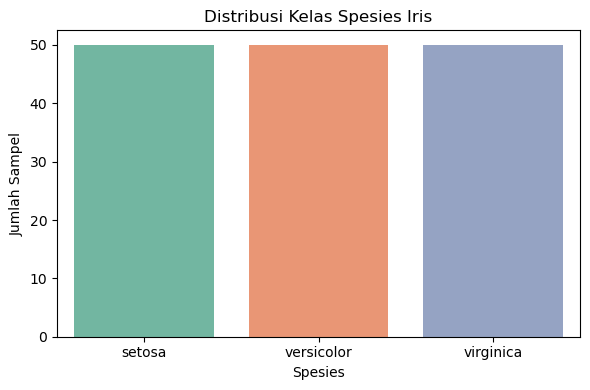

In [6]:
# Distribusi kelas
print('=== Distribusi Kelas ===')
print(df['species_name'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='species_name', palette='Set2')
plt.title('Distribusi Kelas Spesies Iris')
plt.xlabel('Spesies')
plt.ylabel('Jumlah Sampel')
plt.tight_layout()
plt.show()

## 4.3 Distribusi Fitur

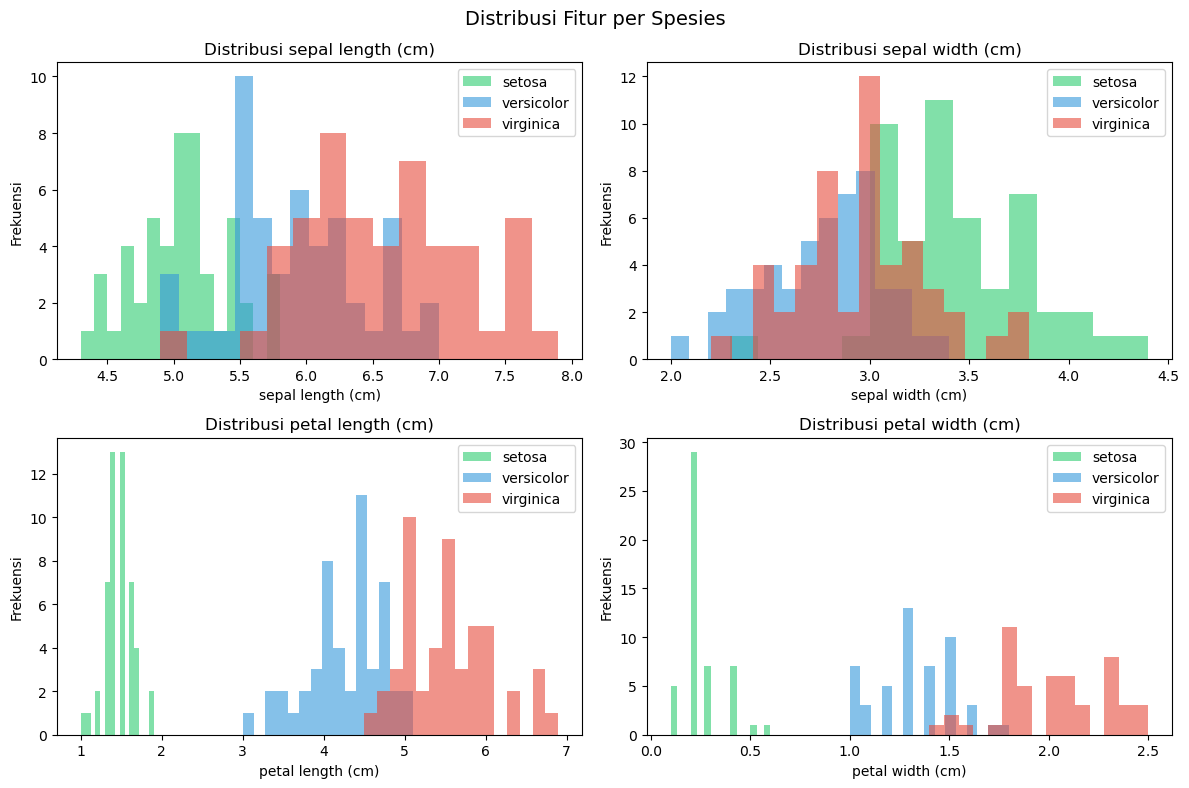

In [7]:
# Histogram semua fitur
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = iris.feature_names

for i, feature in enumerate(features):
    ax = axes[i // 2][i % 2]
    for species, color in zip(['setosa', 'versicolor', 'virginica'], ['#2ecc71', '#3498db', '#e74c3c']):
        subset = df[df['species_name'] == species]
        ax.hist(subset[feature], alpha=0.6, label=species, color=color, bins=15)
    ax.set_title(f'Distribusi {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frekuensi')
    ax.legend()

plt.suptitle('Distribusi Fitur per Spesies', fontsize=14)
plt.tight_layout()
plt.show()

## 4.4 Korelasi Antar Fitur

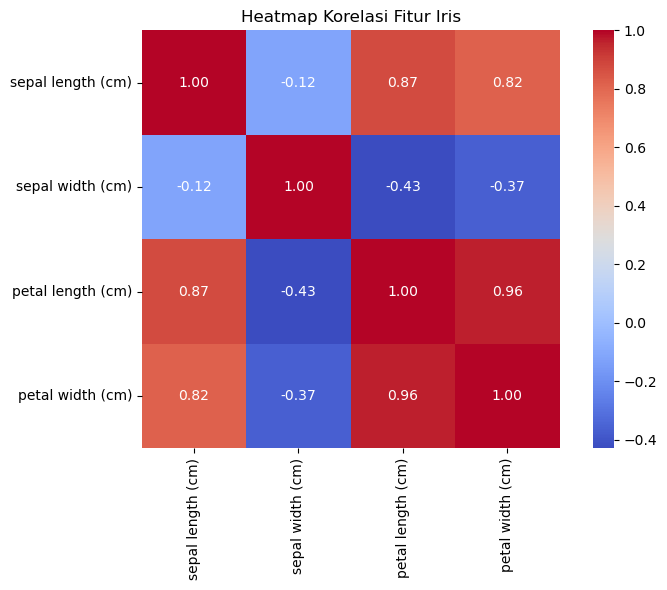

Fitur dengan korelasi tertinggi:
petal length (cm)  petal width (cm)     0.962865
sepal length (cm)  petal length (cm)    0.871754
                   petal width (cm)     0.817941
dtype: float64


In [8]:
# Heatmap korelasi
plt.figure(figsize=(8, 6))
corr_matrix = df[features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Heatmap Korelasi Fitur Iris')
plt.tight_layout()
plt.show()

print('Fitur dengan korelasi tertinggi:')
print(corr_matrix.unstack().sort_values(ascending=False).drop_duplicates()[1:4])

## 4.5 Boxplot (Deteksi Outlier Visual)

C:\Users\monar\AppData\Local\Temp\ipykernel_12168\3045043036.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=feature, palette='Set2', ax=ax)
C:\Users\monar\AppData\Local\Temp\ipykernel_12168\3045043036.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=feature, palette='Set2', ax=ax)
C:\Users\monar\AppData\Local\Temp\ipykernel_12168\3045043036.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species_name', y=feature, palette='Set2', ax=ax)
C:\Users\monar\AppData\Lo

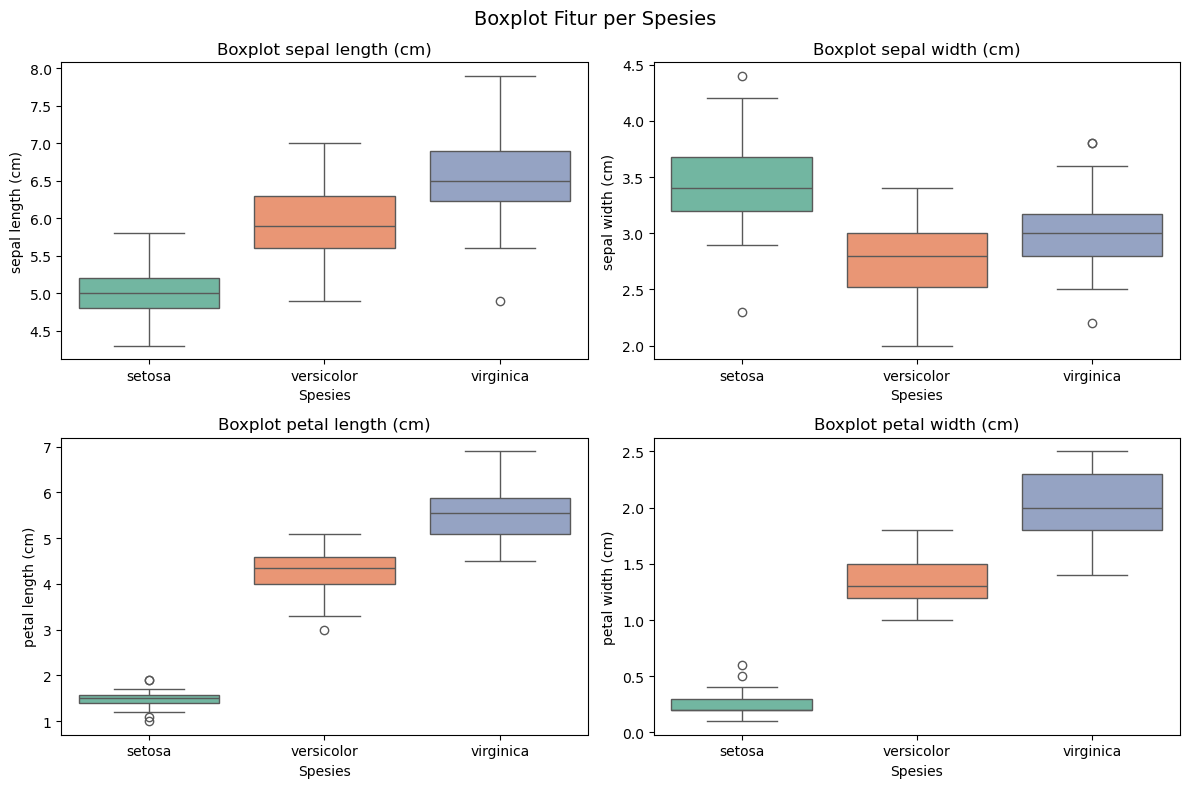

In [9]:
# Boxplot per fitur
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, feature in enumerate(features):
    ax = axes[i // 2][i % 2]
    sns.boxplot(data=df, x='species_name', y=feature, palette='Set2', ax=ax)
    ax.set_title(f'Boxplot {feature}')
    ax.set_xlabel('Spesies')

plt.suptitle('Boxplot Fitur per Spesies', fontsize=14)
plt.tight_layout()
plt.show()

## 4.6 Pairplot

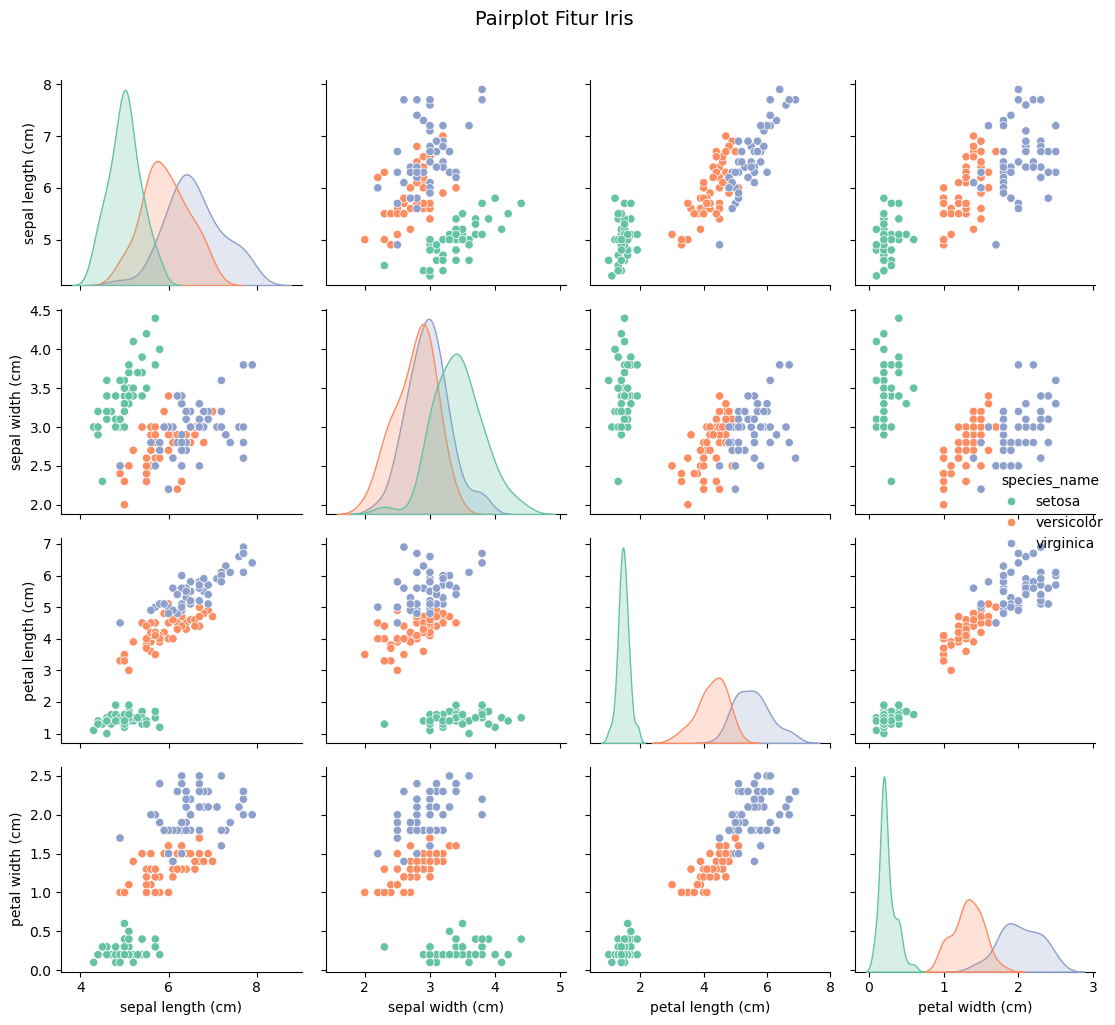

In [10]:
# Pairplot untuk melihat hubungan antar fitur
sns.pairplot(df[features + ['species_name']], hue='species_name', palette='Set2', diag_kind='kde')
plt.suptitle('Pairplot Fitur Iris', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Tahapan preprocessing yang dilakukan:
1. Menghapus data duplikat (jika ada)
2. Menangani missing values (jika ada)
3. Encoding label target
4. Standarisasi fitur numerik (StandardScaler)
5. Split data train dan test
6. Menyimpan hasil preprocessing

## 5.1 Menghapus Duplikat

In [11]:
df_clean = df.copy()

# Hapus duplikat
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f'Baris sebelum dedup: {before}')
print(f'Baris setelah dedup: {after}')
print(f'Baris dihapus: {before - after}')

Baris sebelum dedup: 150
Baris setelah dedup: 149
Baris dihapus: 1


## 5.2 Menangani Missing Values

In [12]:
# Cek ulang missing values setelah dedup
print('Missing values setelah pembersihan:')
print(df_clean.isnull().sum())

# Isi missing values dengan median jika ada (untuk antisipasi)
for col in features:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'Kolom {col}: diisi dengan median = {median_val}')

print('\nMissing values setelah handling:')
print(df_clean.isnull().sum())

Missing values setelah pembersihan:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

Missing values setelah handling:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64


## 5.3 Encoding Label Target

In [13]:
# Kolom 'species' sudah berupa integer (0, 1, 2) — tidak perlu LabelEncoder
# Tapi kita tetap pisahkan fitur dan target
X = df_clean[features]
y = df_clean['species']

print('Fitur (X):')
print(X.head())
print(f'\nTarget (y): {y.unique()} -> {list(zip(y.unique(), ["setosa", "versicolor", "virginica"]))}')

Fitur (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y): [0 1 2] -> [(np.int64(0), 'setosa'), (np.int64(1), 'versicolor'), (np.int64(2), 'virginica')]


## 5.4 Split Data Train dan Test

In [14]:
# Split 80:20 dengan stratify agar distribusi kelas seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Ukuran X_train: {X_train.shape}')
print(f'Ukuran X_test : {X_test.shape}')
print(f'\nDistribusi y_train:')
print(y_train.value_counts())
print(f'\nDistribusi y_test:')
print(y_test.value_counts())

Ukuran X_train: (119, 4)
Ukuran X_test : (30, 4)

Distribusi y_train:
species
0    40
1    40
2    39
Name: count, dtype: int64

Distribusi y_test:
species
1    10
2    10
0    10
Name: count, dtype: int64


## 5.5 Standarisasi Fitur

In [15]:
# StandardScaler: fit pada train, transform pada train dan test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Konversi ke DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=features)

print('Statistik X_train setelah standarisasi:')
X_train_scaled.describe().round(4)

Statistik X_train setelah standarisasi:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,119.0000,119.0000,119.0000,119.0000
mean,-0.0000,0.0000,0.0000,0.0000
std,1.0042,1.0042,1.0042,1.0042
min,-1.8585,-2.3944,-1.5092,-1.4426
25%,-0.9068,-0.5867,-1.2257,-1.1797
50%,-0.0740,-0.1348,0.3049,0.1348
75%,0.6398,0.6561,0.7584,0.7920
max,2.4243,3.0287,1.7788,1.7122


## 5.6 Menyimpan Dataset Hasil Preprocessing

In [16]:
# Gabungkan kembali fitur dan target
train_preprocessed = X_train_scaled.copy()
train_preprocessed['species'] = y_train.values

test_preprocessed = X_test_scaled.copy()
test_preprocessed['species'] = y_test.values

# Simpan ke folder iris_preprocessing
os.makedirs('iris_preprocessing', exist_ok=True)
train_preprocessed.to_csv('iris_preprocessing/iris_train.csv', index=False)
test_preprocessed.to_csv('iris_preprocessing/iris_test.csv',  index=False)

print('Dataset preprocessing berhasil disimpan!')
print('- iris_preprocessing/iris_train.csv')
print('- iris_preprocessing/iris_test.csv')
print(f'\nShape train: {train_preprocessed.shape}')
print(f'Shape test : {test_preprocessed.shape}')
train_preprocessed.head()

Dataset preprocessing berhasil disimpan!
- iris_preprocessing/iris_train.csv
- iris_preprocessing/iris_test.csv

Shape train: (119, 5)
Shape test : (30, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,-1.501587,0.769031,-1.339093,-1.179737,0
1,0.639824,-0.586742,1.041834,1.186365,2
2,-0.192947,-0.134818,0.248192,0.003314,1
3,-0.906751,1.672881,-1.055649,-1.048287,0
4,-1.263653,0.091144,-1.225715,-1.311187,0
